In [211]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pmdarima import auto_arima
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from google.colab import drive

In [176]:
warnings.filterwarnings("ignore")
drive.mount('/content/drive')

In [181]:
rohitsahoo_sales_forecasting_df = pd.read_csv('rohitsahoo-sales-forecasting.csv')

In [182]:
rohitsahoo_sales_forecasting_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [183]:
rohitsahoo_sales_forecasting_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [184]:
rohitsahoo_sales_forecasting_df['Order Date'] = pd.to_datetime(rohitsahoo_sales_forecasting_df['Order Date'], format = '%d/%m/%Y')

In [185]:
monthly_sales = rohitsahoo_sales_forecasting_df.groupby(pd.Grouper(key = 'Order Date', freq = 'ME'))['Sales'].sum()

In [11]:
monthly_sales.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


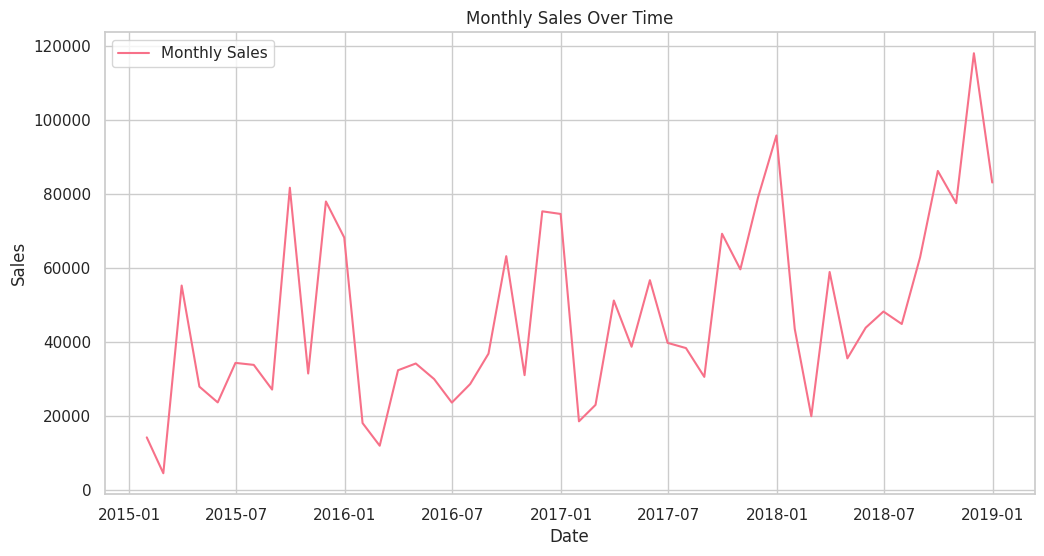

In [189]:
plt.figure(figsize = (12, 6))
plt.plot(monthly_sales, label = 'Monthly Sales')
plt.title('Monthly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

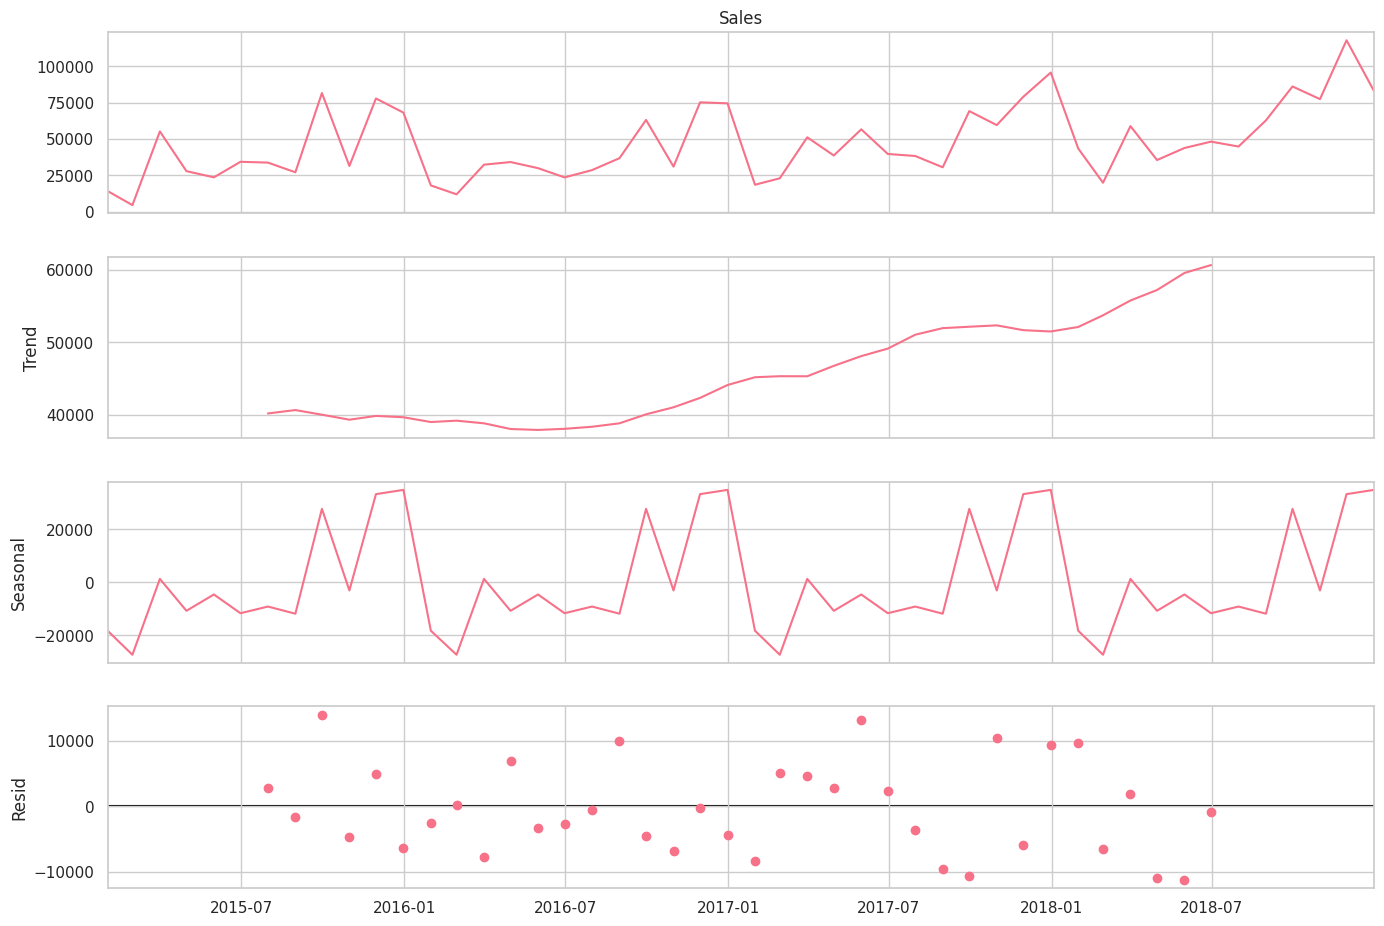

In [202]:
decomposition = seasonal_decompose(monthly_sales, model = 'addictive')
fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.show()

In [220]:
def print_adfuller_results(series, significance_level = 0.05):
    print("Results of the Augmented Dickey-Fuller (ADF) Test:\n")

    adf_test = adfuller(series, autolag = 'AIC')

    print(f"Dickey-Fuller (ADF) Test Statistics: {adf_test[0]:.5f}")
    print(f"P-value: {adf_test[1]:.5f}\n")
    print("Critical Values:\n")

    for key, value in adf_test[4].items():
        print(f"{key}: {value:.5f}")
    if adf_test[1] <= significance_level:
        print("\nConclusion: The series is stationary, we reject the null hypothesis.")
    else:
        print("\nConclusion: The series is not statiinary,e cannot reject the null hypothesis.")
        print("\nRecommendation: Apply differentiation before building an ARIMA model.")
print_adfuller_results(monthly_sales)

Results of the Augmented Dickey-Fuller (ADF) Test:

Dickey-Fuller (ADF) Test Statistics: -4.41614
P-value: 0.00028

Critical Values:

1%: -3.57785
5%: -2.92534
10%: -2.60077

Conclusion: The series is stationary, we reject the null hypothesis.


In [191]:
if isinstance(monthly_sales.index, pd.DatetimeIndex):
    monthly_sales.index.freq = 'ME'

In [198]:
moving_average = monthly_sales.rolling(window = 6).mean()

In [192]:
hw_model = ExponentialSmoothing(
    monthly_sales,
    trend = 'add',
    seasonal = 'add',
    seasonal_periods = 12
).fit()

In [193]:
hw_forecast = hw_model.forecast(12)

In [194]:
sarima_model = auto_arima(
    monthly_sales,
    seasonal = True,
    m = 12,
    trace = False,
    error_action = 'ignore',
    suppress_warnings = True,
    stepwise = True
)

In [203]:
sarima_forecast, conf_int = sarima_model.predict(n_periods = 12, return_conf_int = True)

In [213]:
df_ml = pd.DataFrame({ 'sales' : monthly_sales})
df_ml['month'] = df_ml.index.month
df_ml['year'] = df_ml.index.year
df_ml['trend'] = range(len(df_ml))

In [214]:
X_train = df_ml[['month', 'year', 'trend']]
y_train = df_ml['sales']

In [215]:
last_date = df_ml.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months = 1), periods = 12, freq = 'ME')
future_df = pd.DataFrame(index=future_dates)
future_df['month'] = future_df.index.month
future_df['year'] = future_df.index.year
future_df['trend'] = range(len(df_ml), len(df_ml) + 12)

In [216]:
xgb_model = XGBRegressor(n_estimators = 100, learning_rate = 0.1, objective = 'reg:squarederror')
xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(future_df[['month', 'year', 'trend']])
xgb_forecast = pd.Series(xgb_predictions, index=future_dates)

In [217]:
rf_model = RandomForestRegressor(n_estimators = 100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(future_df[['month', 'year', 'trend']])
rf_forecast = pd.Series(rf_predictions, index=future_dates)

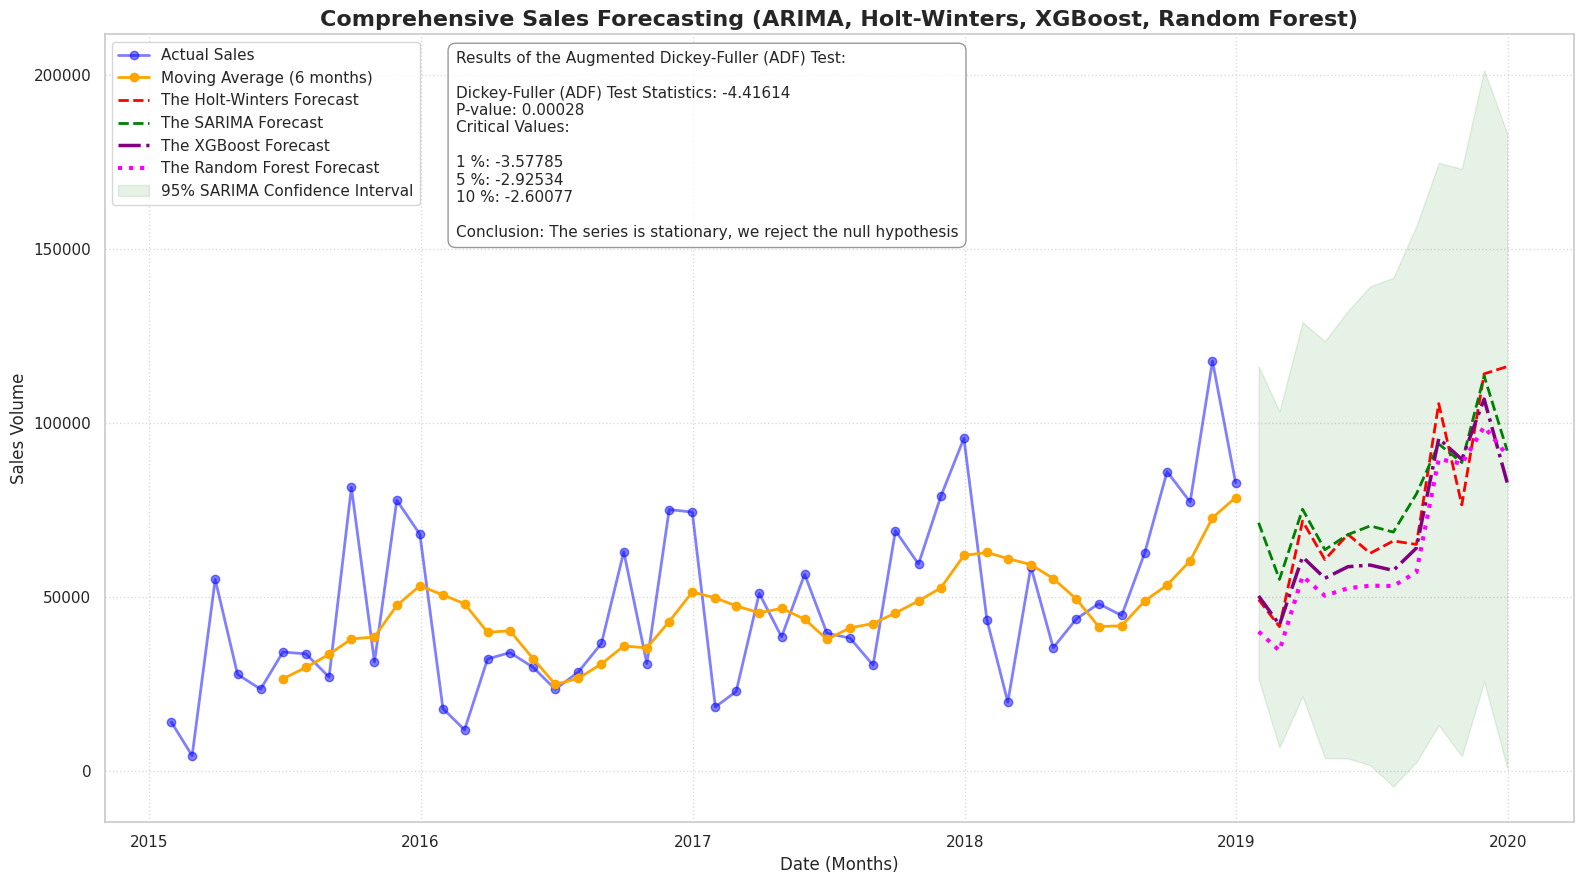

In [239]:
plt.figure(figsize = (16, 9))
plt.plot(monthly_sales.index, monthly_sales, label = 'Actual Sales', color = 'blue', marker = 'o', linewidth = 2, alpha = 0.5)
plt.plot(moving_average.index, moving_average, label = 'Moving Average (6 months)', color = 'orange', marker = 'o', linestyle = '-', linewidth = 2)
plt.plot(hw_forecast.index, hw_forecast, label = 'The Holt-Winters Forecast', color = 'red', linestyle = '--', linewidth = 2)
plt.plot(sarima_forecast.index, sarima_forecast, label = 'The SARIMA Forecast', color = 'green', linestyle = '--', linewidth = 2)
plt.plot(xgb_forecast.index, xgb_forecast, label = 'The XGBoost Forecast', color = 'purple', linestyle = '-.', linewidth = 2.5)
plt.plot(rf_forecast.index, rf_forecast, label = 'The Random Forest Forecast', color = 'magenta', linestyle = ':', linewidth = 3)
plt.fill_between(
    sarima_forecast.index,
    conf_int[:, 0],
    conf_int[:, 1],
    color = 'green',
    alpha = 0.1,
    label = '95% SARIMA Confidence Interval'
)
plt.text(
    0.239,
    0.979,
    "Results of the Augmented Dickey-Fuller (ADF) Test:\n\nDickey-Fuller (ADF) Test Statistics: -4.41614\nP-value: 0.00028\nCritical Values:\n\n1 %: -3.57785\n5 %: -2.92534\n10 %: -2.60077\n\nConclusion: The series is stationary, we reject the null hypothesis",
    transform = plt.gca().transAxes,
    fontsize = 11,
    verticalalignment = 'top',
    bbox = dict(boxstyle = 'round, pad = 0.5', facecolor = 'white', alpha = 0.8, edgecolor = 'gray')
)
plt.title('Comprehensive Sales Forecasting (ARIMA, Holt-Winters, XGBoost, Random Forest)', fontsize = 16, fontweight = 'bold')
plt.xlabel('Date (Months)', fontsize = 12)
plt.ylabel('Sales Volume', fontsize = 12)
plt.legend(loc='upper left', fontsize = 11)
plt.grid(True, linestyle = ':', alpha = 0.7)
plt.tight_layout()
plt.show()